# Chapter 09 텍스트를 위한 인공 신경망
## 09-1 순차 데이터와 순환 신경망
### 순차 데이터
* **순차 데이터sequential data**는 텍스트나 **시계열 데이터time series data**와 같이 순서에 의미가 있는 데이터를 말함. 예를 들어 "I am a boy"는 쉽게 이해할 수 있지만 "boy am a I"는 말이 되지 않음.
* 이 장에서 사용하려는 댓글, 즉 테스트 데이터는 단어의 순서가 중요한 순차 데이터. 이런 데이터는 순서를 유지하며 신경망에 주입해야 함.
* 따라서 순차 데이터를 다룰 때는 이전에 입력한 데이터를 기억하는 기능이 필요. 예를 들어 "별로지만 추천해요"에서 "추천해요"가 입력될 때 "별로지만"을 기억하고 있어야 이 댓글을 무조건 긍정적이라고 판단하지 않을 것.
* 완전 연결 신경망이나 합성곱 신경망은 이런 기억 장치가 없음. 하나의 샘플(또는 하나의 배치)을 사용하여 정방향 계산을 수행하고 나면 그 샘플은 버려지고 다음 샘플을 처리할 때 재사용하지 않음.
* 이렇게 입력 데이터의 흐름이 앞으로만 전달되는 신경망을 **피드포워드 신경망feedforward neural network, FFNN**이라고 함. 이전 장에서 배웠던 완전 연결 신경망과 합성곱 신경망이 모두 피드포워드 신경망에 속함.
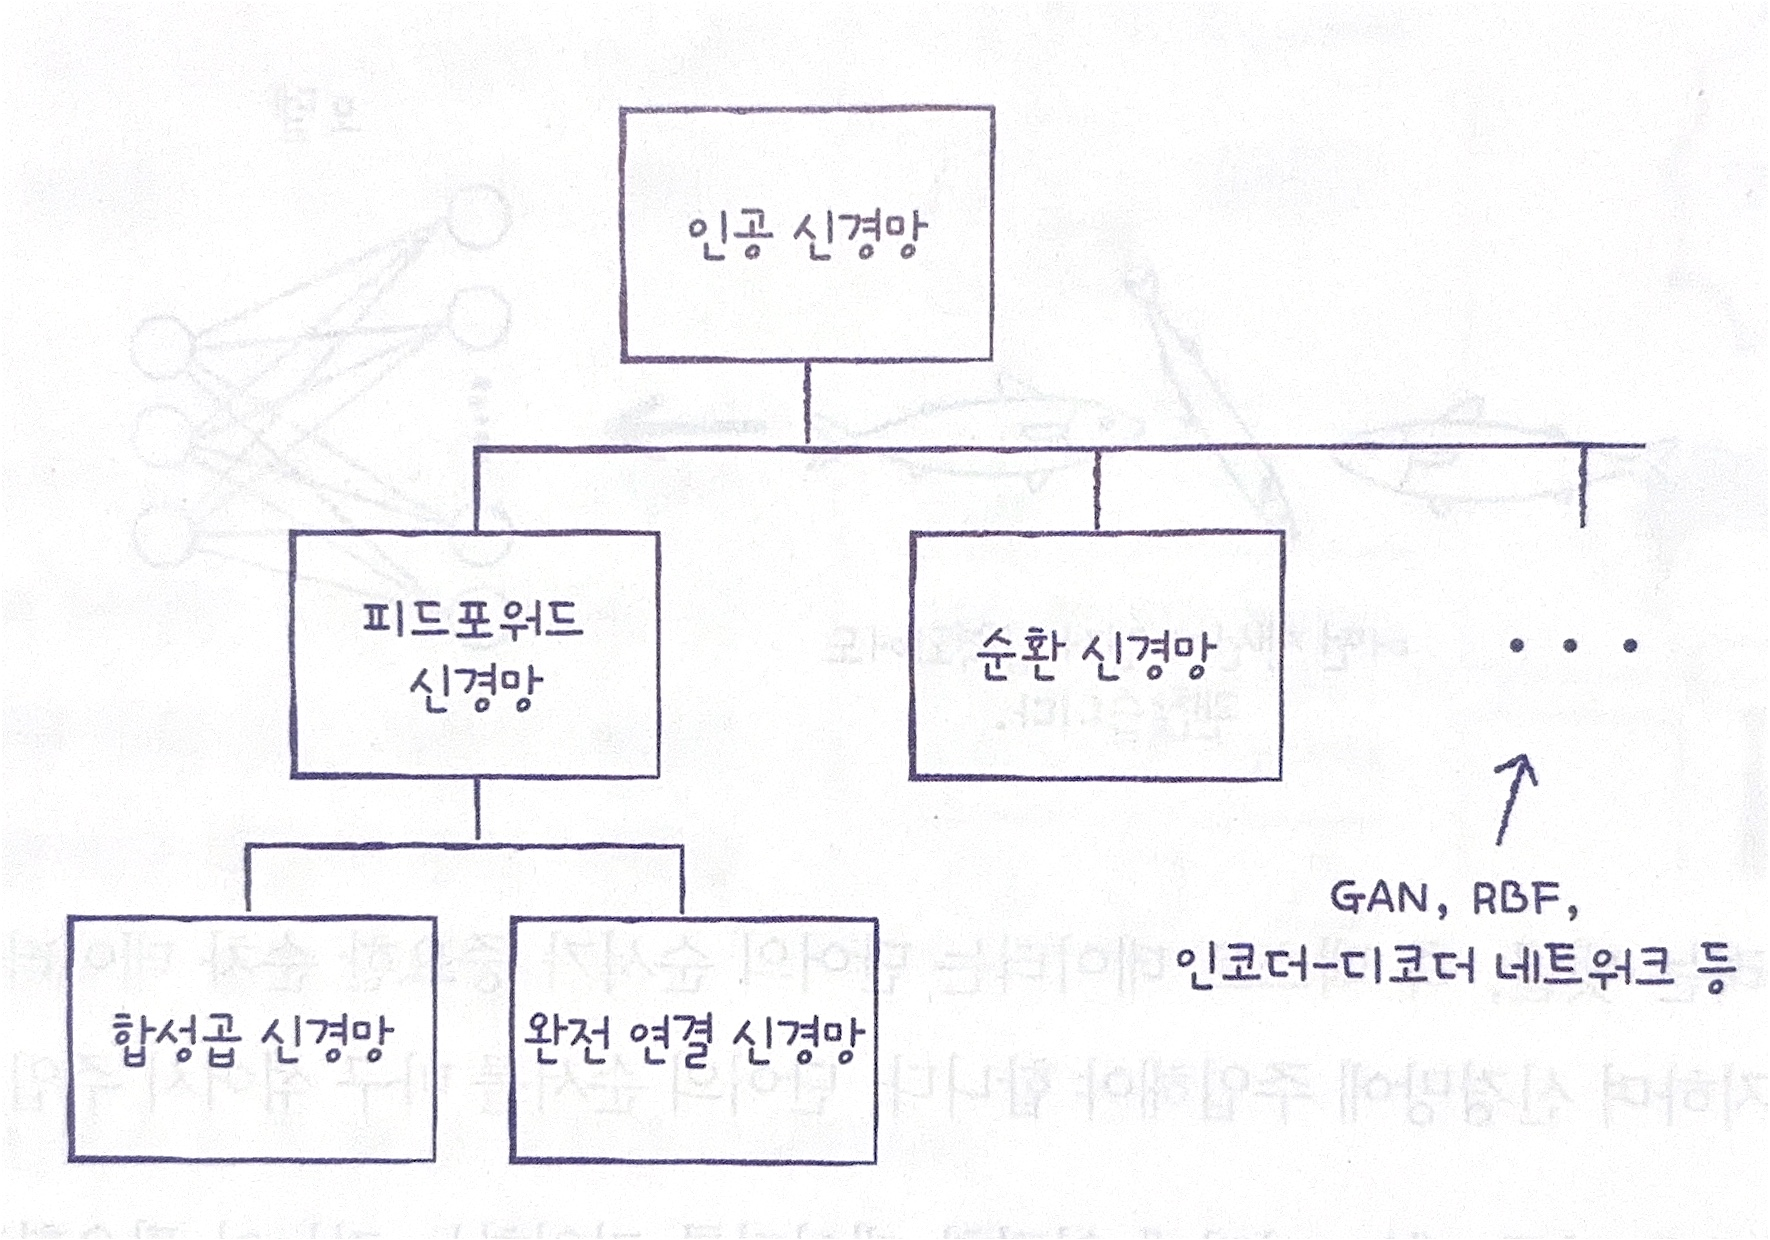
* 신경망이 이전에 처리했던 샘플을 다음 샘플을 처리하는데 재사용하기 위해서는 이렇게 데이터 흐름이 앞으로만 전달되어서는 곤란. 다음 샘플을 위해서 이전 데이터가 신경망 층에 순환될 필요가 있음. 이런 신경망이 바로 순환 신경망.

### 순환 신경망
* **순환 신경망recurrent neural network, RNN**은 일반적인 완전 연결 신경망과 거의 비슷. 완전 연결 신경망에 이전 데이터의 처리 흐름을 순환하는 고리 하나만 추가하면 됨.
* 뉴런의 출력이 다시 자기 자신으로 전달됨. 즉 어떤 샘플을 처리할 때 바로 이전에 사용했던 데이터를 재사용하는 셈.
* 그래서 순환 신경망에서는 '이전 샘플에 대한 기억을 가지고 있다'고 종종 말함. 이렇게 샘플을 처리하는 한 단계를 **타임스텝timestep**이라고 말함.
* 순환 신경망은 이전 타임스텝의 샘플을 기억하지만 타임스텝이 오래될수록 순환되는 정보는 희미해짐.
* 순환 신경망에서는 특별히 층을 **셀cell**이라고 부름. 한 셀에는 여러 개의 뉴런이 있지만 완전 연결 신경망과 달리 뉴런을 모두 표시하지 않고 하나의 셀로 층을 표현. 또 셀의 출력을 **은닉 상태hidden state**라고 부름.
* 합성곱 신경망에서처럼 신경망의 구조마다 조금씩 부르는 이름이 다를 수 있음. 하지만 기본 구조는 같음.
* 달라지는 것은 층의 출력(즉 은닉 상태)을 다음 타임 스텝에 재사용한다는 것뿐.
* 일반적으로 은닉층의 활성화 함수로는 하이퍼볼릭 탄젠트hyperbolic tangent 함수인 $tanh^{2}$가 많이 사용됨. tanh 함수도 S자 모양을 띄기 때문에 종종 시그모이드 함수라고 부르기도 함.
* 다른 신경망과 마찬가지로 순환 신경망 그림에도 번거로움을 피하긱 위해 활성화 함수를 표시하지 않는 경우가 많음. 하지만 순환 신경망에도 활성화 함수각 반드시 필요하다는 것을 꼭 기억할 것.
* 합성곱 신경망과 같은 피드포워드 신경망에서 뉴런은 입력과 가중치를 곱함. 순환 신경망에서도 동일. 다만 순환 신경망의 뉴런은 가중치가 하나 더 있음. 바로 이전 타임스텝의 은닉 상태에 곱해지는 가중치. 셀은 입력과 이전 타임스텝의 은닉 상태를 사용하여 현재 타임스텝의 은닉 상태를 만듦.
* 모든 타임스텝에서 사용되는 가중치는 $w_{b}$ 하나라는 점. 가중치 $w_{b}$는 타임스텝에 따라 변화되는 뉴런의 출력을 학습.
* 그럼 맨 처음 타임스텝1에서 사용되는 이전 은닉 상태 $h_{0}$은 어떻게 구할 수 있을까? 맨 처음 샘플을 입력할 때는 이전 타임스텝이 없음. 따라서 간단히 $h_{0}$은 모두 0으로 초기화.

### 셀의 가중치와 입출력
* 예를 들어 순환층에 입력되는 특성의 개수가 4개이고 순환층의 뉴런이 3개라고 가정.
* 먼저 $w_{x}$의 크기를 구해 봄. 입력층과 순환층의 뉴런이 모두 완전 연결되기 때문에 가중치 $w_{x}$의 크기는 4 $\times$ 3 = 12개가 됨.
* 그럼 순환층에서 다음 타임스텝에 재사용되는 은닉 상태를 위한 가중치 $w_{h}$의 크기는?
* 순환층에 있는 첫 번째 뉴런($r_{1}$)의 은닉 상태가 다음 타임스텝에 재사용될 때 첫 번째 뉴런과 두 번째 뉴런, 세 번째 뉴런에 모두 전달됨. 즉 이전 타임스텝의 은닉 상태는 다음 타임스텝의 뉴런에 완전히 연결됨!
* 두 번째 뉴런의 은닉 상태도 마찬가지로 첫 번째 뉴런과 두 번째 뉴런, 세 번째 뉴런에 모두 전달되고, 세 번째 뉴런의 은닉 상태도 동일. 따라서 이 순환층에서 은닉 상태를 위한 가중치 $w_{b}$는 3 $\times$ 3 = 9개.
* 가중치는 모두 구했으니 모델 파라미터 개수를 계산해볼까? 가중치에 절편을 더하면 됨. 여기엔 각 뉴런마다 하나의 절편이 있음. 따라서 이 순환층은 모두 12 + 9 + 3 = 24개의 모델 파라미터를 가지고 있음. 이제 왜 순환층을 셀 하나로 표시할 수밖에 없는지 이해되나? 은닉 상태가 모든 뉴런에 순환되기 때문에 완전 연결 신경망처럼 그림으로 표현하기는 너무 어려움.
* 이전 장에서 배웠던 합성곱 층의 입력은 전형적으로 하나의 샘플이 3개의 차원을 가짐. 너비, 높이, 채널. 입력이 합성곱 층과 풀링 층을 통과하면 너비, 높이, 채널(혹은 깊이)의 크기가 달라지지만 차원의 개수는 그대로 유지되었음.
* 순환층은 일반적으로 샘플마다 2개의 차원을 가짐. 보통 하나의 샘플을 하나의 시퀀스sequence라고 말함. 시퀀스 안에는 여러 개의 아이템이 들어 있음. 여기서 시퀀스의 길이가 바로 타임스텝 길이.
* 앞에서는 셀이 모든 타임스텝에서 출력을 만든 것처럼 표현했음. 하지만 사실 순환층은 기본적으로 마지막 타임스텝의 은닉 상태만 출력으로 내보냄.
* 이는 마치 입력된 시퀀스 길이를 모두 읽어서 정보를 마지막 은닉 상태에 압축하여 전달하는 것처럼 볼 수 있음. 이제 순환 신경망이 정보를 기억하는 메모리를 가진다고 표현하는지 이해할 수 있음. 또 순환 신경망이 순차 데이터에 잘 맞는 이유를 파악할 수 있음.
* 순환 신경망도 완전 연결 신경망이나 합성곱 신경망처럼 여러 개의 층을 쌓을 수 있음. 순환층을 여러 개 쌓았을 때는 셀의 출력은 어떻게 달라질까? 셀의 입력은 샘플마다 타임스텝과 단어 표현으로 이루어진 2차원 배열이어야 함. 따라서 첫 번째 셀이 마지막 타임스텝의 은닉 상태만 출력해서는 안 됨. 이런 경우에는 마지막 셀을 제외한 다른 모든 셀은 모든 타임스텝의 은닉 상태를 출력.
* 합성곱 신경망과 마찬가지로 순환 신경망도 마지막에는 밀집층을 두어 클래스를 분류. 다중 분류일 경우에는 출력층에 클래스 개수만큼 뉴런을 두고 소프트맥스 활성화 함수를 사용. 이진 분류일 경우에는 하나의 뉴런을 두고 시그모이드 활성화 함수를 사용.
* 합성곱 신경망과 다른 점은 마지막 셀의 출력이 1차원이기 때문에 Flatten 클래스로 펼칠 필요가 없음. 셀의 출력을 그대로 밀집층에 사용할 수 있음.